In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [44]:
file_path = "Top 10 Healthcare Companies in the United States.xlsx"
united_raw = pd.read_excel(
    file_path, sheet_name="UnitedHealth Group Inc. (UNH)", header=None
)

In [45]:
united_raw.shape

(5893, 5)

In [46]:
united_raw.head()

,0,1,2,3,4
0,UNH,NaN,NaN,NaN,NaN
1,StartDate,2000. 1. 1,NaN,NaN,NaN
2,EndDate,2023. 5. 27,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Date,Close,High,Low,Volume


In [47]:
df = united_raw.iloc[5:, :5].copy()
df.columns = ["Date", "Close", "High", "Low", "Volume"]
df = df.reset_index(drop=True)

In [48]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for col in ["Close", "High", "Low", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["Date", "Close"]).reset_index(drop=True)
df = df.sort_values("Date").reset_index(drop=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_15688\2147216187.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"],errors="coerce")


In [54]:
df = united_raw.iloc[5:].copy()
df.columns = ["Date", "Close", "High", "Low", "Volume"]
df = df.reset_index(drop=True)

In [55]:
df.tail()

,Date,Close,High,Low,Volume
5883,2023. 5. 19 오후 4:00:00,478.82,484.8,477.81,2318047
5884,2023. 5. 22 오후 4:00:00,480.62,482.2,477.91,2242831
5885,2023. 5. 23 오후 4:00:00,479.44,483.39,472.54,2874407
5886,2023. 5. 24 오후 4:00:00,480.83,483.28,478.89,1904673
5887,2023. 5. 25 오후 4:00:00,477.7,481.77,474.3,2684136


In [56]:
df.shape

(5888, 5)

In [57]:
df.head()

,Date,Close,High,Low,Volume
0,2000. 1. 3 오후 4:00:00,6.72,6.75,6.62,399600
1,2000. 1. 4 오후 4:00:00,6.63,6.78,6.62,669200
2,2000. 1. 5 오후 4:00:00,6.62,6.77,6.58,1205800
3,2000. 1. 6 오후 4:00:00,6.9,6.94,6.61,1617600
4,2000. 1. 7 오후 4:00:00,7.66,7.69,7.11,1807900


In [59]:
df["Date"] = df["Date"].astype(str).str.extract(r"(\d{4}\.\s*\d{1,2}\.\s*\d{1,2})")[0]
df["Date"] = pd.to_datetime(df["Date"], format="%Y. %m. %d", errors="coerce")

In [60]:
for col in ["Close", "High", "Low", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [61]:
df = df.dropna(subset=["Date", "Close"]).reset_index(drop=True)
df = df.sort_values("Date").reset_index(drop=True)

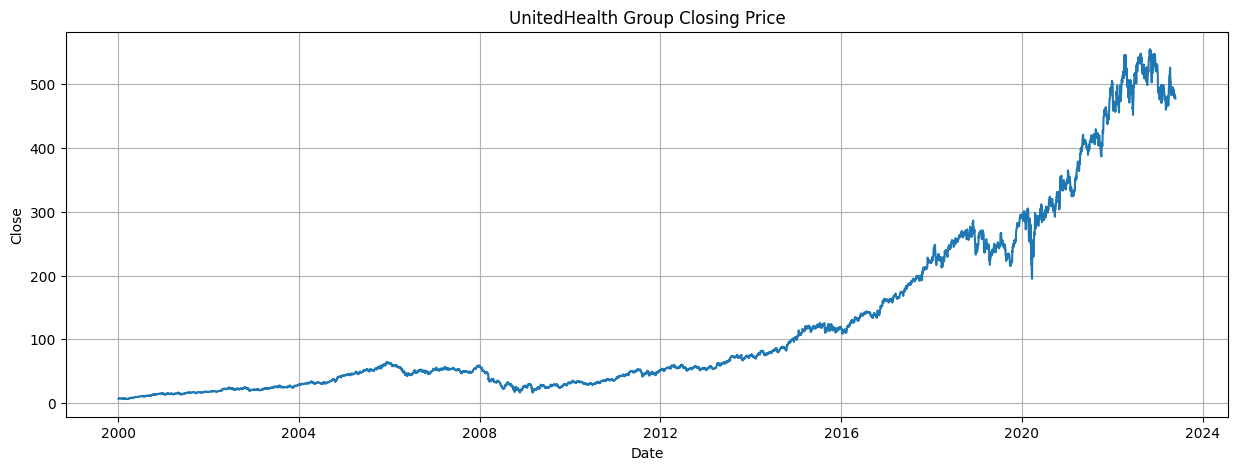

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Close"])
plt.title("UnitedHealth Group Closing Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()

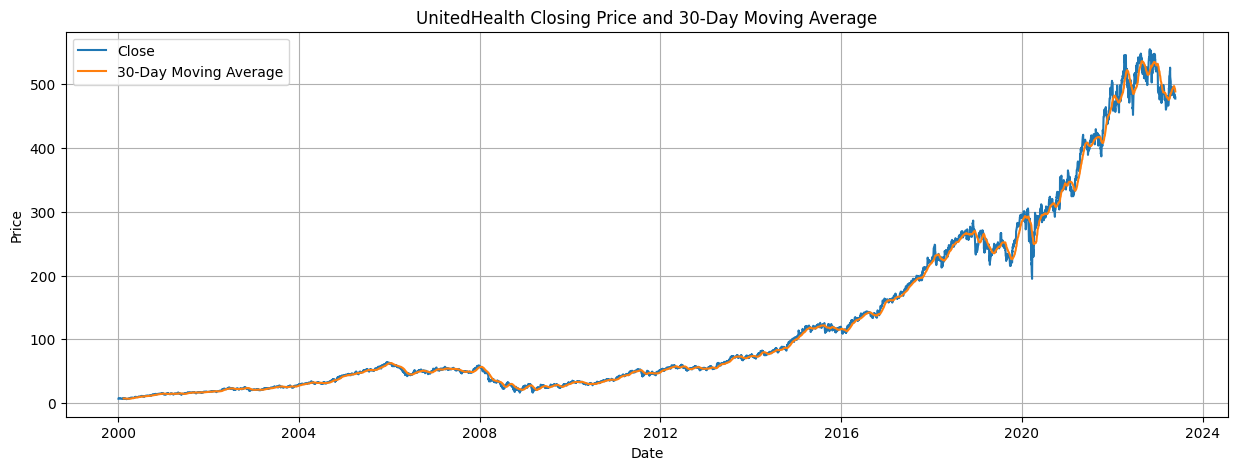

In [63]:
df["MA_30"] = df["Close"].rolling(30).mean()
plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA_30"], label="30-Day Moving Average")
plt.title("UnitedHealth Closing Price and 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

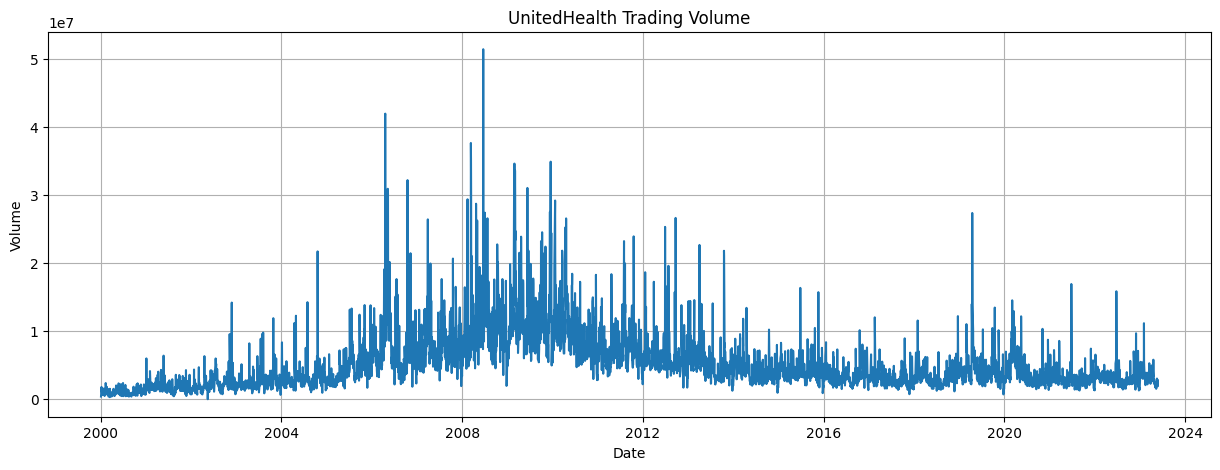

In [64]:
plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Volume"])
plt.title("UnitedHealth Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

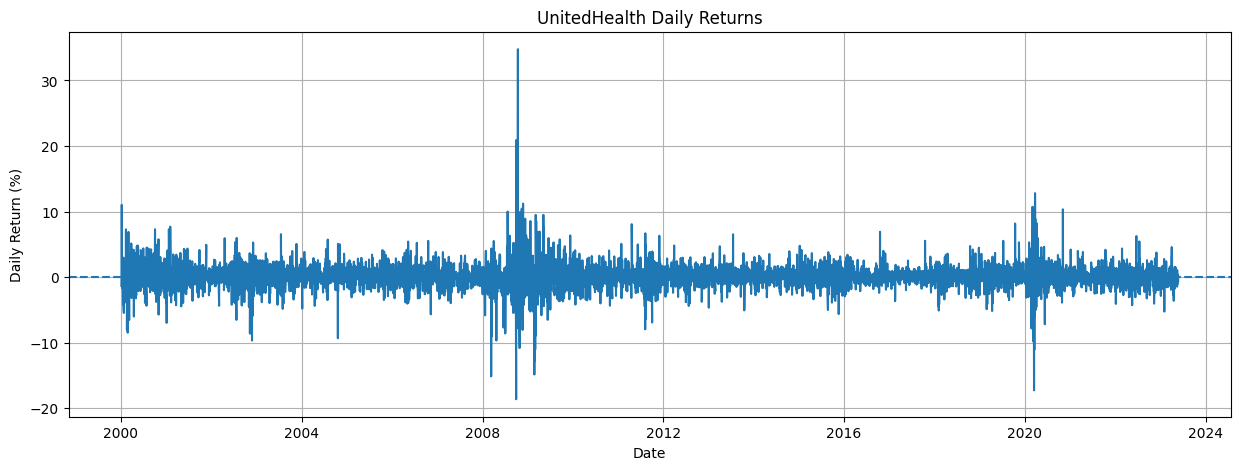

In [ ]:
df["Daily_Return"] = df["Close"].pct_change() * 100
plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Daily_Return"])
plt.axhline(0, linestyle="--")
plt.title("UnitedHealth Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.grid(True)
plt.show()

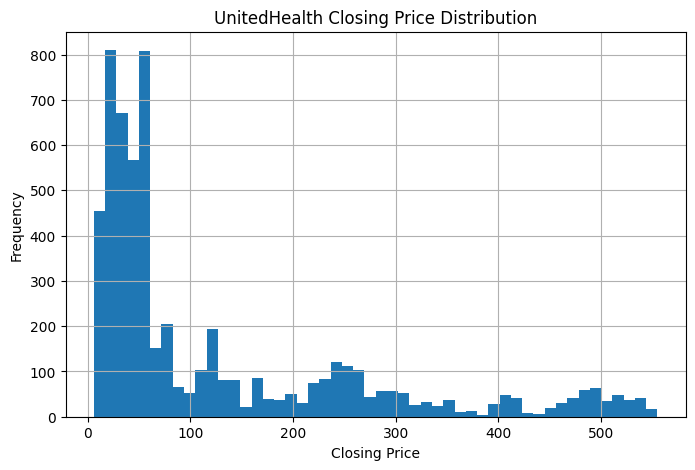

In [66]:
plt.figure(figsize=(8, 5))
plt.hist(df["Close"].dropna(), bins=50)
plt.title("UnitedHealth Closing Price Distribution")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [67]:
train_size = int(len(df) * 0.80)
train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

In [68]:
print("Train:", train.shape)
print("Test:", test.shape)

Train: (4710, 7)
Test: (1178, 7)


In [69]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[["Close"]])
test_scaled = scaler.transform(test[["Close"]])

In [70]:
lookback = 60
X_train = []
y_train = []
for i in range(lookback, len(train_scaled)):
    X_train.append(train_scaled[i - lookback : i, 0])
    y_train.append(train_scaled[i, 0])
X_train = np.array(X_train)
y_train = np.array(y_train)

In [71]:
combined = np.concatenate([train_scaled[-lookback:], test_scaled])
X_test = []
y_test = []
for i in range(lookback, len(combined)):
    X_test.append(combined[i - lookback : i, 0])
    y_test.append(combined[i, 0])
X_test = np.array(X_test)
y_test = np.array(y_test)

In [72]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [73]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (4650, 60, 1)
X_test: (1178, 60, 1)


In [74]:
gru_model = Sequential(
    [
        GRU(32, return_sequences=True, input_shape=(60, 1)),
        Dropout(0.2),
        GRU(16),
        Dropout(0.2),
        Dense(8, activation="relu"),
        Dense(1),
    ]
)

c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [75]:
gru_model.compile(optimizer="adam", loss="mse")

In [76]:
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 32)         │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,905 (23.07 KB)

 Trainable params: 5,905 (23.07 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
early_stopping = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [78]:
history = gru_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 124ms/step - loss: 0.0060 - val_loss: 0.0015
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 9.4890e-04 - val_loss: 0.0087
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 6.3740e-04 - val_loss: 0.0101
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 4.9813e-04 - val_loss: 0.0105
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 3.9615e-04 - val_loss: 0.0119
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 3.6560e-04 - val_loss: 0.0149


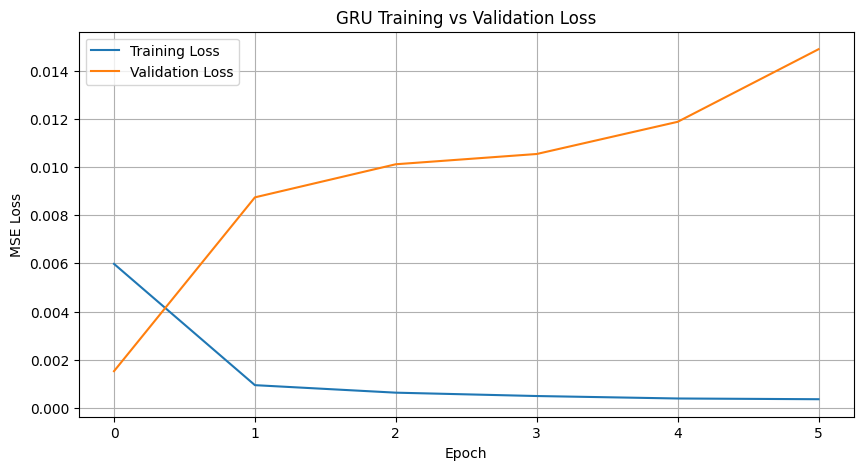

In [79]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("GRU Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

In [80]:
pred_scaled = gru_model.predict(X_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step


In [81]:
pred = scaler.inverse_transform(pred_scaled).flatten()

In [82]:
actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [83]:
print(pred.shape)
print(actual.shape)

(1178,)
(1178,)


In [84]:
mae = mean_absolute_error(actual, pred)

In [85]:
mse = mean_squared_error(actual, pred)

In [86]:
rmse = np.sqrt(mse)

In [87]:
mape = np.mean(np.abs((actual - pred) / actual)) * 100

In [88]:
r2 = r2_score(actual, pred)

In [89]:
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

MAE  : 57.7263
MSE  : 5162.5466
RMSE : 71.8509
MAPE : 13.59%
R²   : 0.5372


In [90]:
prediction_df = pd.DataFrame(
    {"Date": test["Date"].values, "Actual_Close": actual, "Predicted_Close": pred}
)

In [91]:
prediction_df.head(20)

,Date,Actual_Close,Predicted_Close
0,2018-09-20,266.39,247.966934
1,2018-09-21,266.67,248.230316
2,2018-09-24,267.36,248.569916
3,2018-09-25,263.51,248.967789
4,2018-09-26,262.91,248.904343
5,2018-09-27,264.65,248.586731
6,2018-09-28,266.04,248.404419
7,2018-10-01,269.10,248.463715
8,2018-10-02,270.63,248.956711
9,2018-10-03,270.90,249.730011


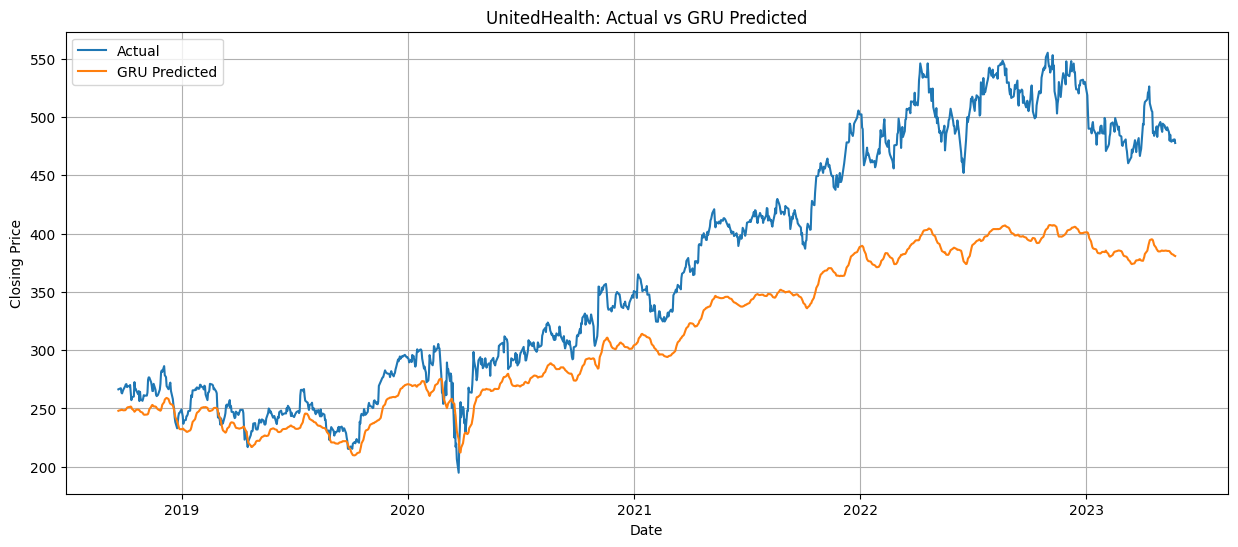

In [92]:
plt.figure(figsize=(15, 6))
plt.plot(prediction_df["Date"], prediction_df["Actual_Close"], label="Actual")
plt.plot(prediction_df["Date"], prediction_df["Predicted_Close"], label="GRU Predicted")
plt.title("UnitedHealth: Actual vs GRU Predicted")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

In [93]:
latest_60 = df["Close"].tail(60).values.reshape(-1, 1)
latest_scaled = scaler.transform(latest_60)
X_next = latest_scaled.reshape(1, 60, 1)
next_scaled = gru_model.predict(X_next)
next_price = scaler.inverse_transform(next_scaled)[0][0]
last_price = df["Close"].iloc[-1]
change = next_price - last_price
change_percent = (change / last_price) * 100

c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


In [95]:
forecast = pd.DataFrame(
    {
        "Last_Actual_Close": [last_price],
        "Predicted_Next_Day_Close": [next_price],
        "Expected_Change": [change],
        "Expected_Change_Percent": [change_percent],
    }
)

In [96]:
forecast

,Last_Actual_Close,Predicted_Next_Day_Close,Expected_Change,Expected_Change_Percent
0,477.7,380.416443,-97.283557,-20.36499
